In [1]:
from ggner_3d.cm import get_expected_cis_df, MCOOLS_PATH_DICT

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
colors = plotting.COLORS + ['#8A6E59']
RESOLUTION = 10_000

In [2]:
def prepare_log_expected(sample_name):
    cvd_smooth_agg = get_expected_cis_df(sample_name, RESOLUTION//1000)
    cvd_smooth_agg.loc[
    cvd_smooth_agg['dist'] < 2,
    'balanced.avg.smoothed.agg'
] = np.nan
    cvd_merged = cvd_smooth_agg.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
    cvd_merged = cvd_merged.dropna(subset=['balanced.avg.smoothed.agg'])
    return cvd_merged

def calculate_derivative(agg, dist_bp):
    der = np.gradient(np.log10(agg),
                  np.log10(dist_bp))
    return der

def normalize(x, y, target_auc=1.0, norm_type='trapezoidal'):
    x = np.asarray(x)
    y = np.asarray(y)

    if norm_type == 'trapezoidal':
        auc = np.trapezoid(y, x)
        if auc == 0:
            raise ValueError("AUC is zero, cannot normalize.")

        return y * target_auc / auc
    elif norm_type == 'sum':
        total = np.sum(y)
        if total == 0:
            raise ValueError("Sum of y is zero, cannot normalize.")

        return y * target_auc / total

def _prepare_cis(sample_name, upper_thresh=None, norm_type='trapezoidal'):
    merged_df = prepare_log_expected(sample_name)
    dist_bp = merged_df['dist_bp'].values
    agg = merged_df['balanced.avg.smoothed.agg'].values
    agg_normalized = normalize(dist_bp, agg, norm_type=norm_type)
    der = calculate_derivative(agg, dist_bp)

    # filter by upper_thresh
    if upper_thresh is not None:
        mask = dist_bp <= upper_thresh
    else:
        mask = np.ones(len(dist_bp), dtype=bool)
    dist_bp = dist_bp[mask]
    agg = agg[mask]
    agg_normalized = agg_normalized[mask]
    der = der[mask]

    return dist_bp, agg, der, agg_normalized

In [3]:
cis_decay_dict = {}
for k in MCOOLS_PATH_DICT.keys():
    dist_bp, agg, der, agg_normalized = _prepare_cis(k, upper_thresh=None, norm_type='sum')
    cis_decay_dict[k] = {
        'dist_bp': dist_bp,
        'agg': agg,
        'der': der,
        'agg_normalized': agg_normalized
    }

In [4]:
def setup_log(ax, axis='x'):
    if axis == 'x':
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(LogLocator(base=10))
        ax.xaxis.set_major_formatter(LogFormatterSciNotation())
        ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    elif axis == 'y':
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterSciNotation())
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

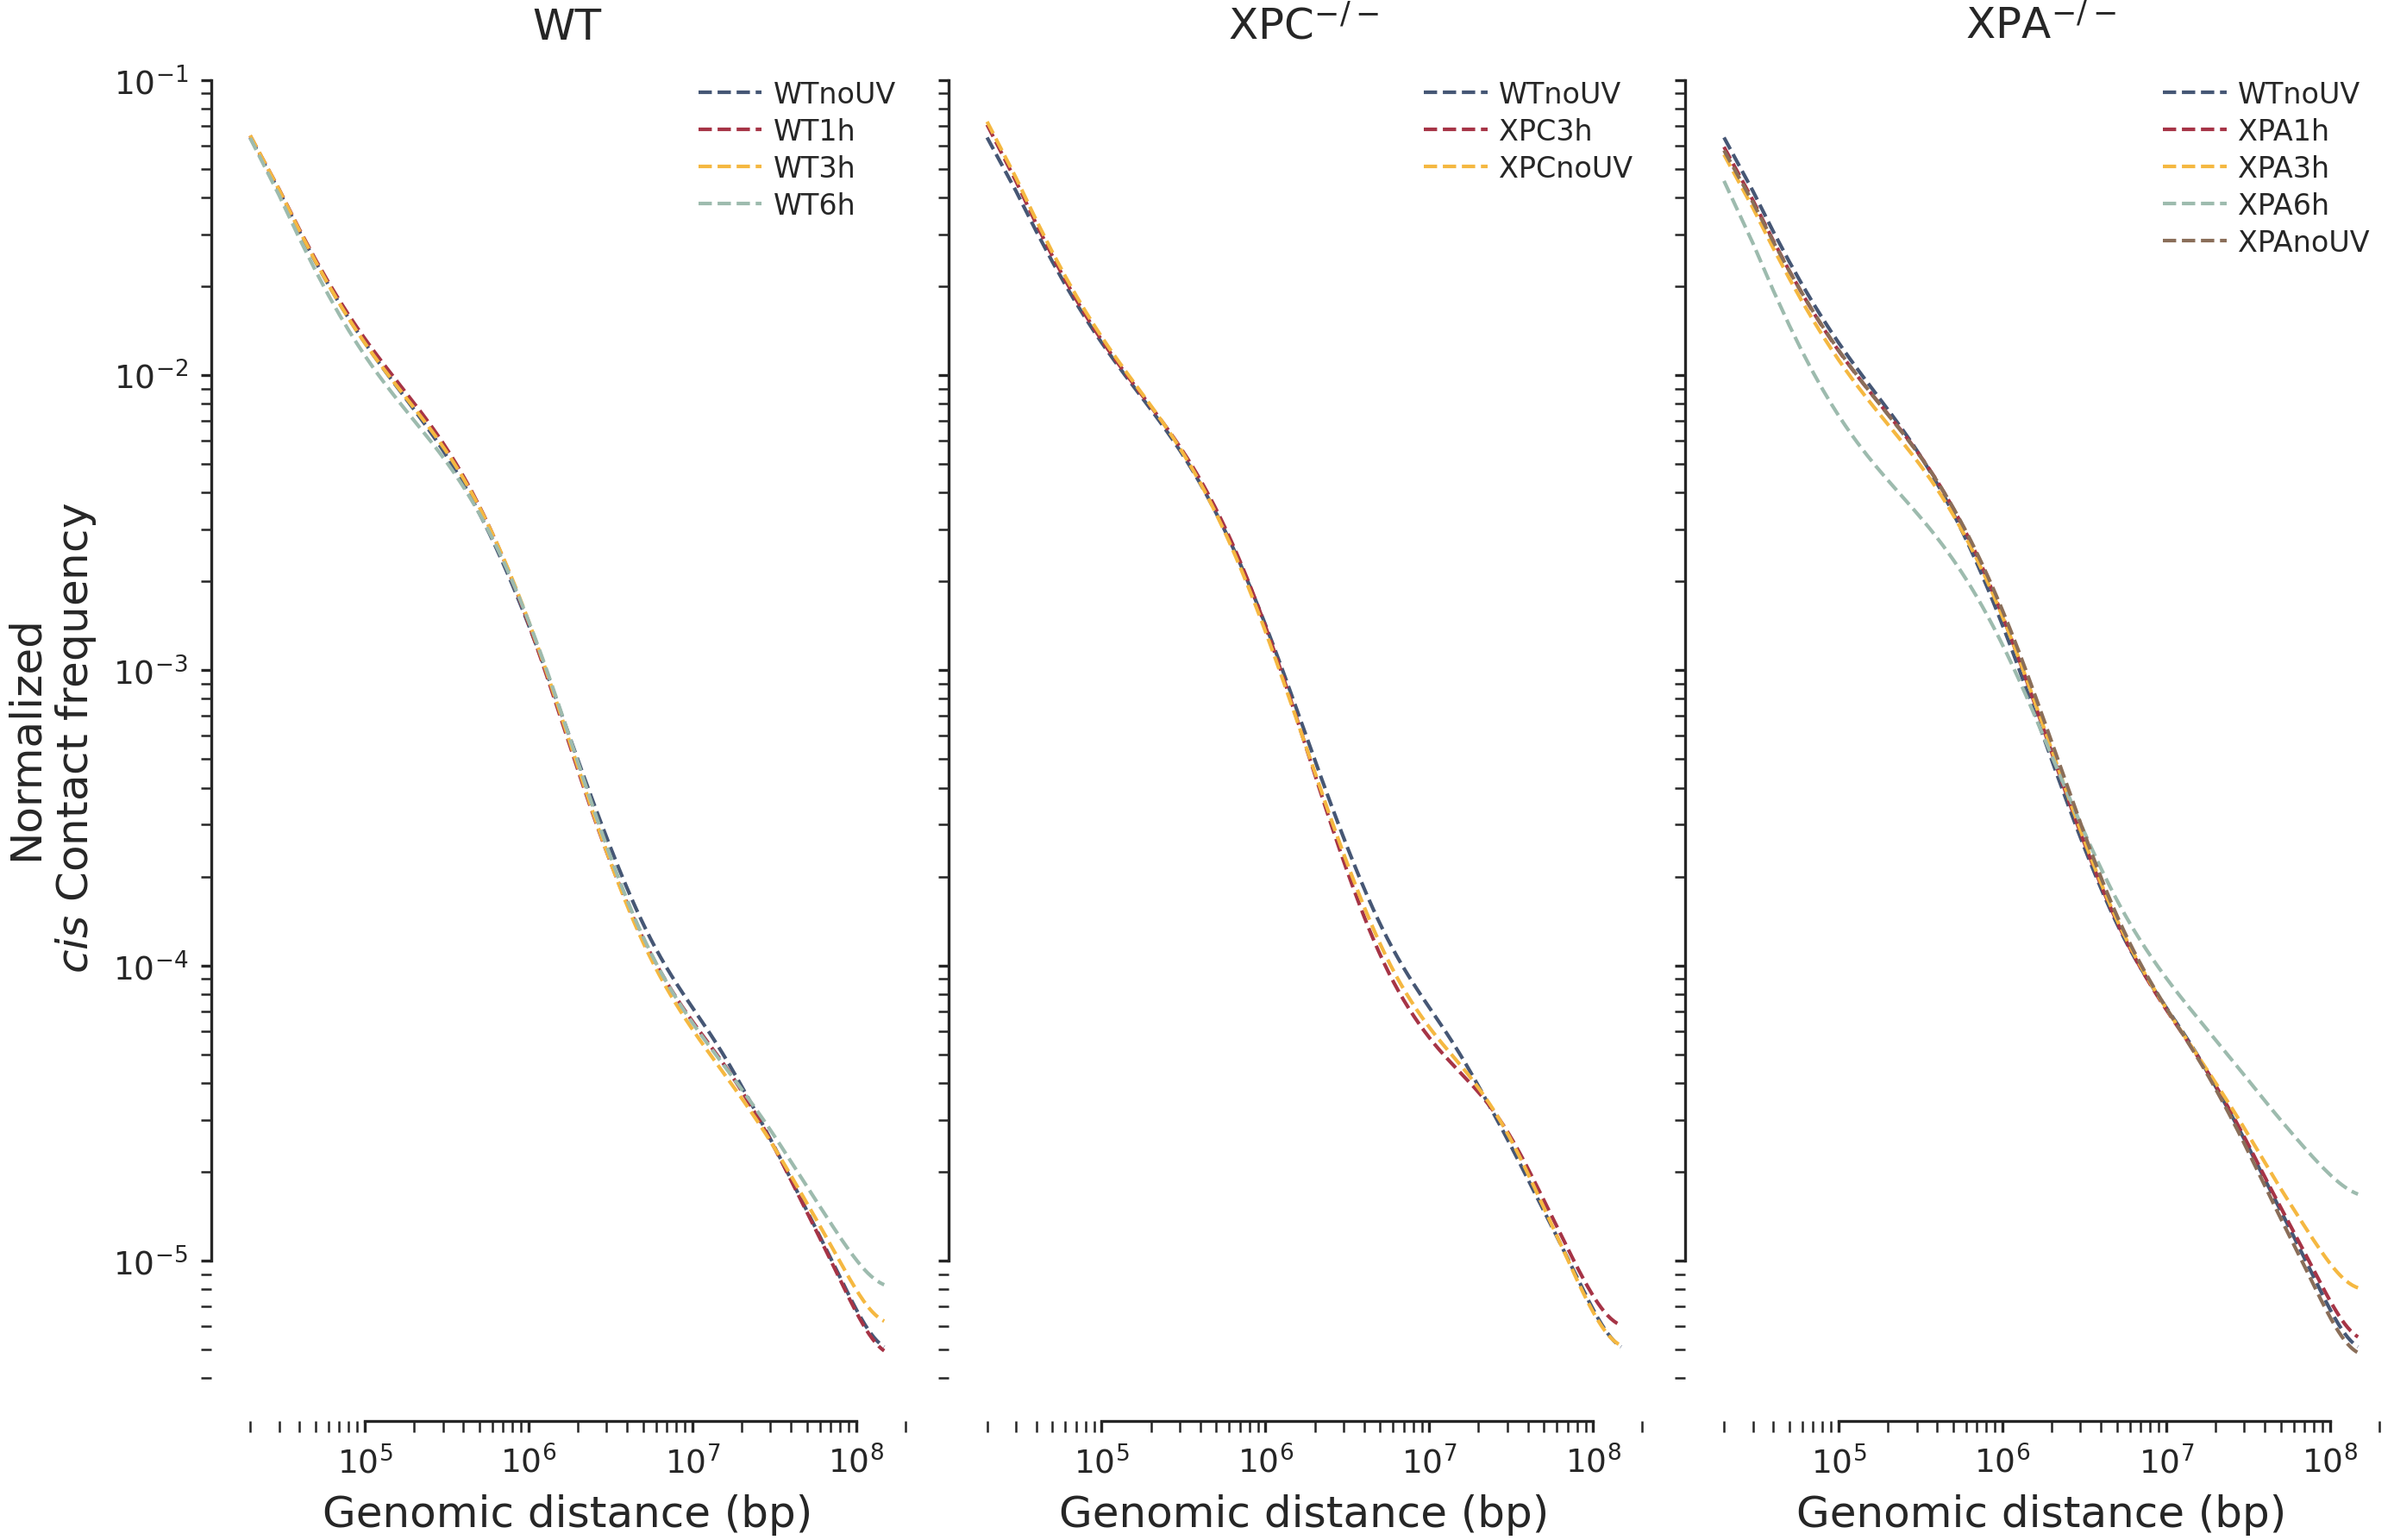

In [5]:
def plot_cis_decay_lines(
    ax,
    keys,
    cis_decay_dict,
    color_map,
    *,
    label_replace=False,
    linewidth=1.0,
    linestyle="--",
    legend=True,
    legend_kwargs=None,
):

    if legend_kwargs is None:
        legend_kwargs = {"frameon": False, "loc": "best", "handlelength": 2.2}

    for k in keys:
        v = cis_decay_dict[k]

        label = k
        if label_replace:
            label = (
                k.replace("WT", "WT-")
                 .replace("XPA", "XPA-")
                 .replace("XPC", "XPC-")
            )

        sns.lineplot(
            ax=ax,
            x=v["dist_bp"],
            y=v["agg_normalized"],
            label=label,
            color=color_map[k],
            linewidth=linewidth,
            linestyle=linestyle,
            errorbar=None,
        )

    setup_log(ax, axis="y")
    setup_log(ax, axis="x")
    ax.set_ylabel("Normalized\n$\\mathit{cis}$ Contact frequency")
    ax.set_xlabel("Genomic distance (bp)")

    if legend:
        ax.legend(**legend_kwargs)

    ax.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax)
    ax.tick_params(axis="both", which="both", direction="out", length=3)

    return ax


wt_base = "WTnoUV"
wt_keys  = ['WTnoUV', 'WT1h', 'WT3h', 'WT6h']
xpc_keys = [wt_base] + sorted([k for k in cis_decay_dict.keys() if "XPC" in k])
xpa_keys = [wt_base] + sorted([k for k in cis_decay_dict.keys() if "XPA" in k])

# Assign colors within each panel
wt_color_map  = {k: colors[i] for i, k in enumerate(wt_keys)}
xpc_color_map = {k: colors[i] for i, k in enumerate(xpc_keys)}
xpa_color_map = {k: colors[i] for i, k in enumerate(xpa_keys)}

fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(3.1 * 3, 6.0),
    constrained_layout=True,
    sharey=True,
)

# Panel 1: WT
plot_cis_decay_lines(ax1, wt_keys, cis_decay_dict, wt_color_map, legend=True)
ax1.set_title("WT")

# Panel 2: XPC knockout
plot_cis_decay_lines(ax2, xpc_keys, cis_decay_dict, xpc_color_map, legend=True)
ax2.set_title(r"XPC$^{-/-}$")
ax2.set_ylabel("")

# Panel 3: XPA knockout
plot_cis_decay_lines(ax3, xpa_keys, cis_decay_dict, xpa_color_map, legend=True)
ax3.set_title(r"XPA$^{-/-}$")
ax3.set_ylabel("")

fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_decay_comparison.svg")

In [6]:
def plot_cis_derivative_and_foldchange(
    cis_decay_dict,
    colors,
    *,
    der_keys=None,                # NEW: explicit keys for derivative panel
    wt_key_filter="WT",           # kept for backwards-compat fallback
    der_key="der",
    x_key="dist_bp",
    y_key="agg_normalized",
    comp_base="WTnoUV",
    comps=("WT1h", "WT3h", "WT6h"),
    figsize=(12.4, 9.0),
    hspace=0.08,
    linewidth=1.6,
    legend=True,
    legend_kwargs=None,
    fold_baseline_line=True,
    label_replace_map=(("WT", "WT-"), ("XPA", "XPA-"), ("XPC", "XPC-")),
):
    """
    2-panel figure:
      (1) derivative (v[der_key]) vs distance for der_keys (default: comp_base + comps)
      (2) fold-change of v[y_key] for comps relative to comp_base

    Requires: setup_log(ax, axis=...), despine(ax)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Default derivative keys: comp_base + comps
    if der_keys is None:
        der_keys = [comp_base] + list(comps)

    # If user passes a single string by accident
    if isinstance(der_keys, str):
        der_keys = [der_keys]

    # Backwards compat: if comps/comp_base not desired, user can still use wt_key_filter by passing der_keys="auto_wt"
    if der_keys == ["auto_wt"]:
        der_keys = sorted([k for k in cis_decay_dict.keys() if wt_key_filter in k])

    # color map for all keys we might plot
    all_keys = sorted(set(list(der_keys) + [comp_base] + list(comps)))

    if legend_kwargs is None:
        legend_kwargs = {"frameon": False, "loc": "best", "handlelength": 2.2}

    fig, (ax1, ax2) = plt.subplots(
        nrows=2,
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"hspace": hspace},
    )

    def _apply_replaces(s: str) -> str:
        for a, b in label_replace_map:
            s = s.replace(a, b)
        return s

    # ----------------------------
    # Panel 1: Derivative plot (comp_base + comps by default)
    # ----------------------------
    for k in der_keys:
        v = cis_decay_dict[k]
        sns.lineplot(
            ax=ax1,
            x=v[x_key],
            y=v[der_key],
            label=_apply_replaces(k),
            color=color_map[k],
            linewidth=linewidth,
            errorbar=None,
        )

    setup_log(ax1, axis="x")
    ax1.set_ylabel(r"Slope of $\log_{10}(\mathrm{Expected}\ \mathit{cis})$")
    if legend:
        ax1.legend(**legend_kwargs)
    ax1.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax1)

    # ----------------------------
    # Panel 2: Fold change plot
    # ----------------------------
    base_x = cis_decay_dict[comp_base][x_key]
    base_y = cis_decay_dict[comp_base][y_key]

    for comp in comps:
        fold_change = cis_decay_dict[comp][y_key] / base_y
        sns.lineplot(
            ax=ax2,
            x=base_x,
            y=fold_change,
            label=f"{_apply_replaces(comp)} / {_apply_replaces(comp_base)}",
            color=color_map[comp],
            linewidth=linewidth,
            errorbar=None,
        )

    if fold_baseline_line:
        ax2.axhline(1.0, color="0.4", linestyle="--", linewidth=1.0, zorder=0)

    setup_log(ax2, axis="x")
    ax2.set_xlabel("Genomic distance (bp)")
    ax2.set_ylabel("Fold change\n(Normalized contact frequency)")
    if legend:
        ax2.legend(**legend_kwargs)
    ax2.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax2)

    # match x-lims to base_x
    ax1.set_xlim(np.nanmin(base_x), np.nanmax(base_x))

    return fig, (ax1, ax2), color_map

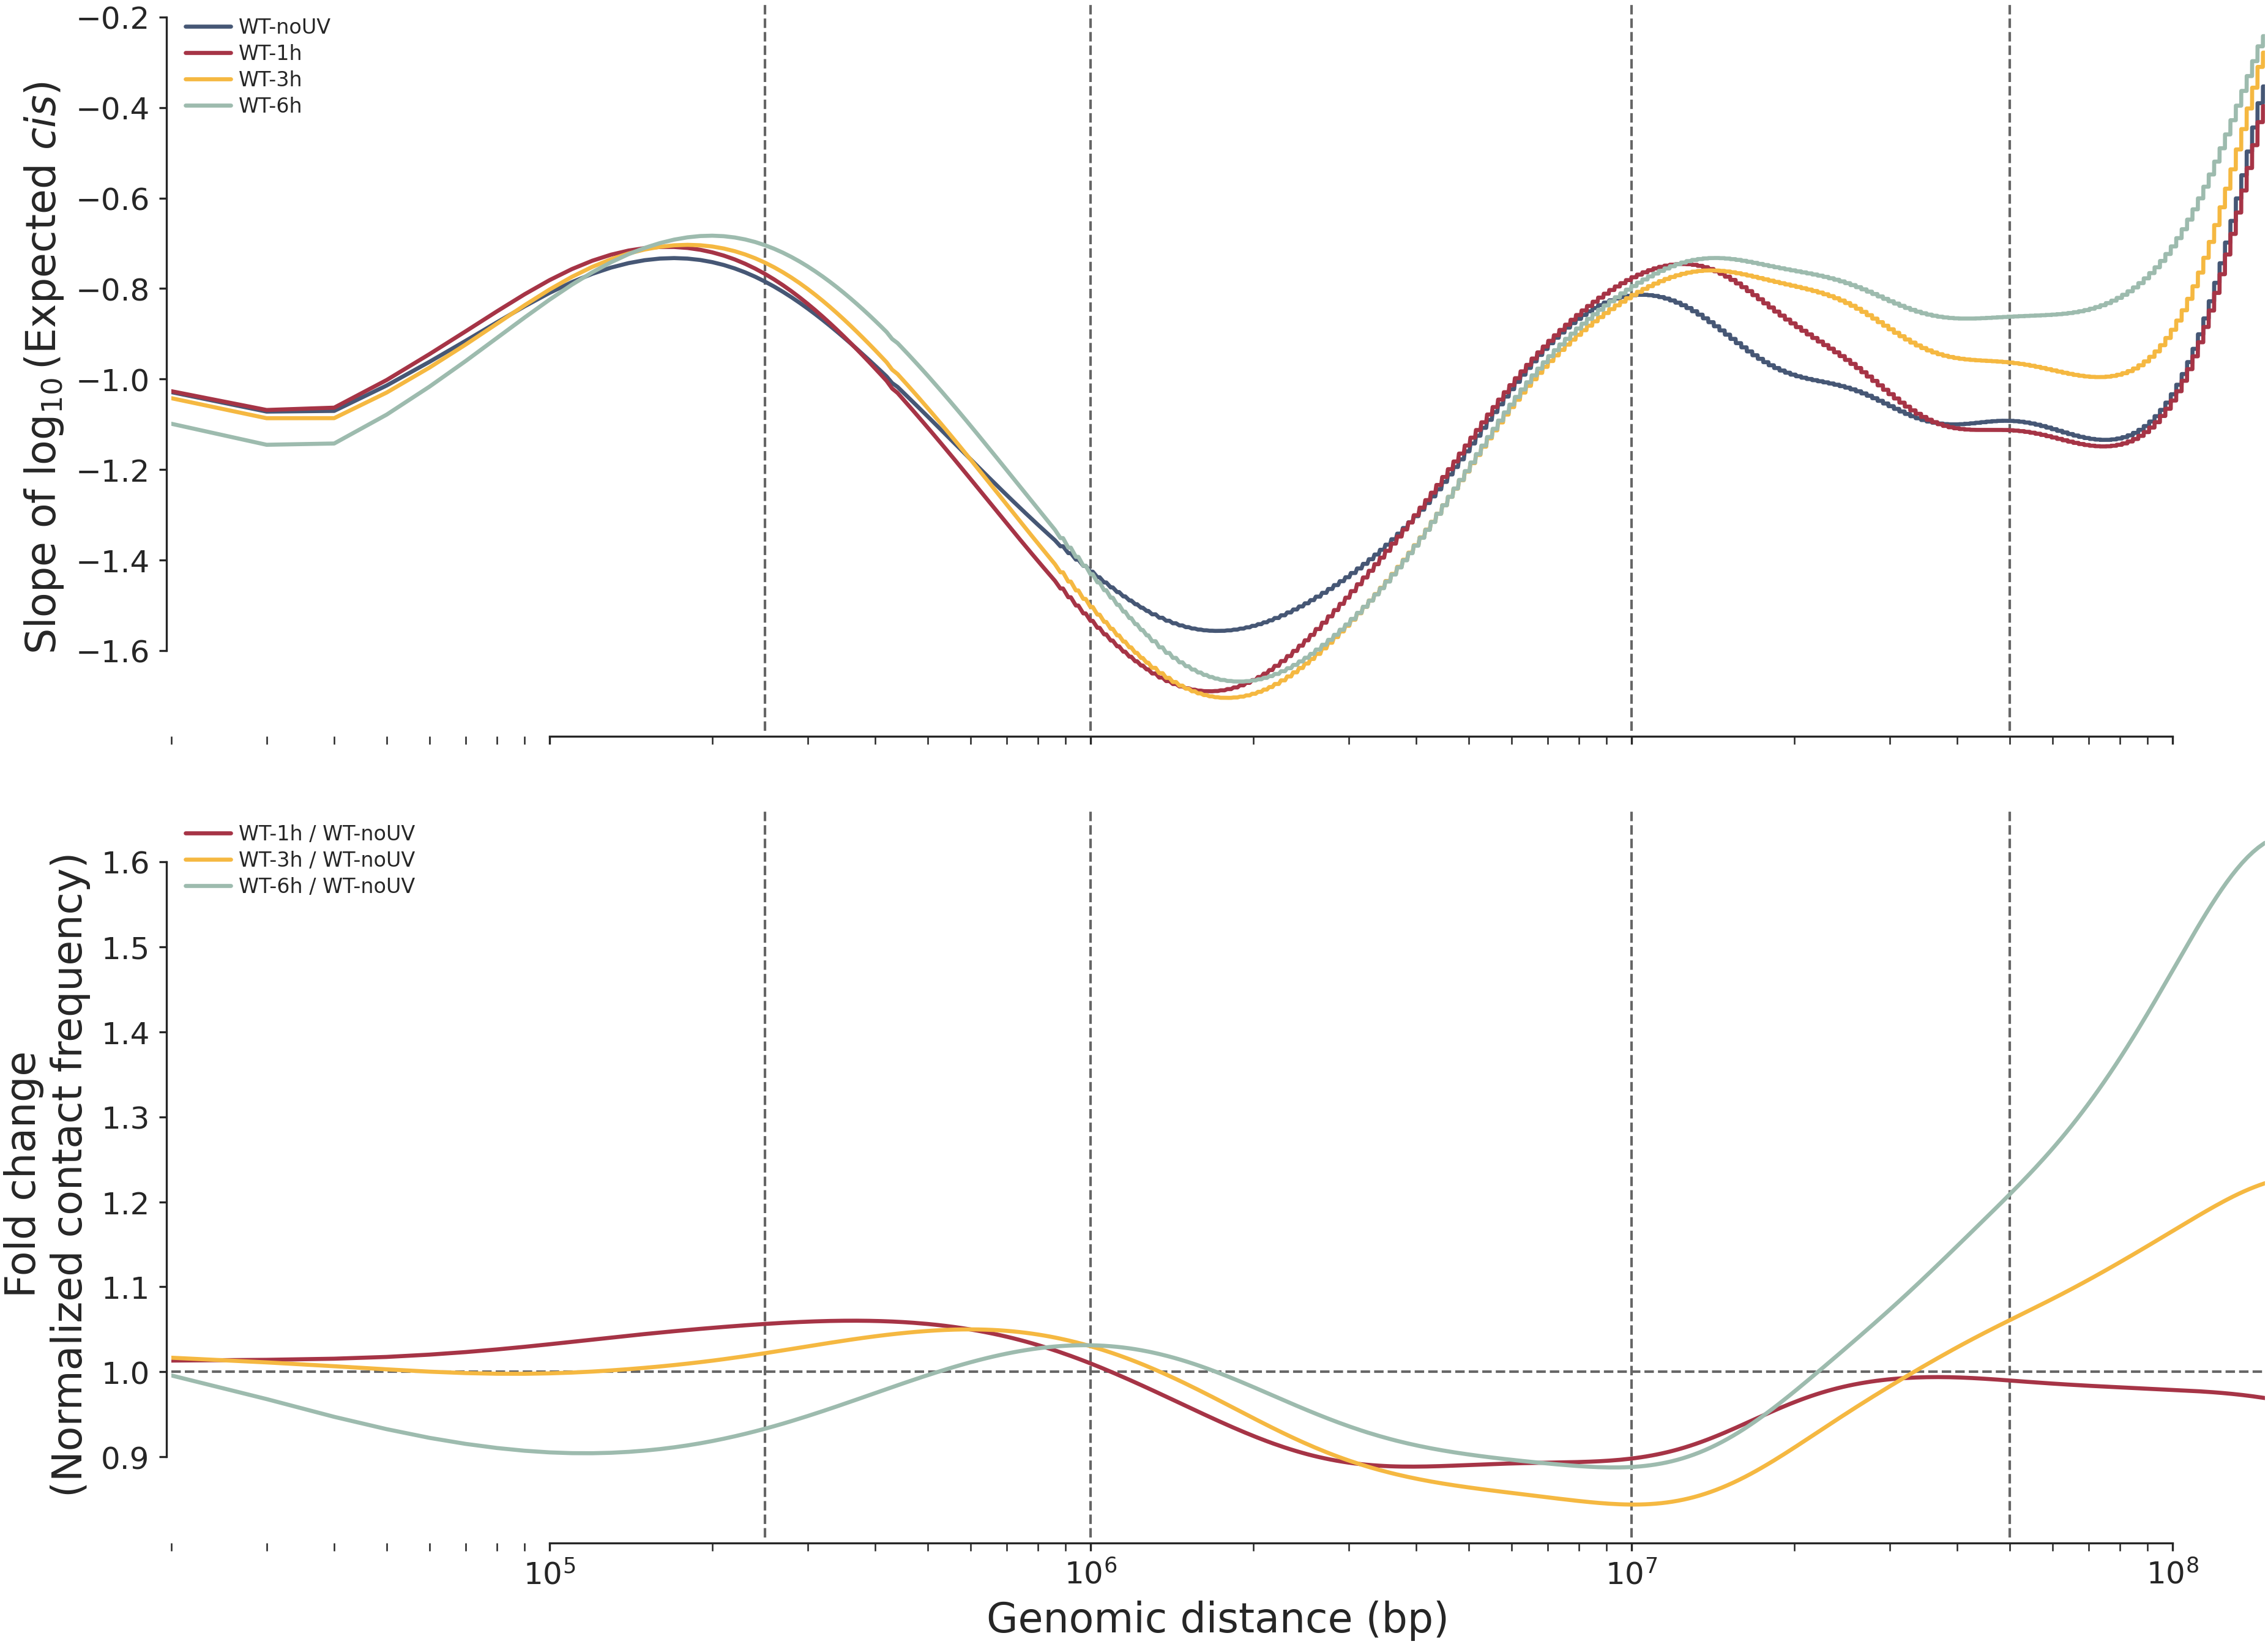

In [7]:
color_map = {'WTnoUV': '#465775', 'WT1h': '#A63446', 'WT3h': '#F5B841', 'WT6h': '#9DBBAE'}

fig, (ax1, ax2), color_map = plot_cis_derivative_and_foldchange(
    cis_decay_dict=cis_decay_dict,
    colors=color_map,
    comp_base="WTnoUV",
    comps=("WT1h", "WT3h", "WT6h"),
)

genome_scale_medians = [
    250_000,      # loops
    1_000_000,    # TADs
    10_000_000,   # compartments
    50_000_000,   # intra-arm
]


# make y and x labels bigger
for ax in (ax1, ax2):
    # make tick labels bigger
    ax.tick_params(axis="both", which="both", direction="out", length=3, labelsize=12)
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    plotting.despine(ax)

for ax in [ax1, ax2]:
    # add vertical line
    for pos in genome_scale_medians:
        ax.axvline(pos, color="0.4", linestyle="--", linewidth=1.0, zorder=0)

fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_derivative_and_foldchange_wt.svg")

In [8]:
def plot_cis_derivative_and_foldchange_axes(
    ax_der,
    ax_fc,
    cis_decay_dict,
    colors,
    *,
    comp_base="WTnoUV",
    comps=(),
    der_keys=None,  # default: [comp_base] + comps
    der_key="der",
    x_key="dist_bp",
    y_key="agg_normalized",
    linewidth=1.6,
    legend=True,
    legend_kwargs=None,
    fold_baseline_line=True,
    label_replace_map=(("WT", "WT-"), ("XPA", "XPA-"), ("XPC", "XPC-")),
):
    import numpy as np
    import seaborn as sns

    if der_keys is None:
        der_keys = [comp_base] + list(comps)
    if isinstance(der_keys, str):
        der_keys = [der_keys]

    all_keys = sorted(set(list(der_keys) + [comp_base] + list(comps)))
    color_map = {k: colors[i % len(colors)] for i, k in enumerate(all_keys)}

    if legend_kwargs is None:
        legend_kwargs = {"frameon": False, "loc": "best", "handlelength": 2.2}

    def _apply_replaces(s: str) -> str:
        for a, b in label_replace_map:
            s = s.replace(a, b)
        return s

    # --- Derivative panel
    for k in der_keys:
        v = cis_decay_dict[k]
        sns.lineplot(
            ax=ax_der,
            x=v[x_key],
            y=v[der_key],
            label=_apply_replaces(k),
            color=color_map[k],
            linewidth=linewidth,
            errorbar=None,
        )
    setup_log(ax_der, axis="x")
    ax_der.set_ylabel(r"Slope of $\log_{10}(\mathrm{Expected}\ \mathit{cis})$")
    if legend:
        ax_der.legend(**legend_kwargs)
    ax_der.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax_der)

    # --- Fold-change panel
    base_x = cis_decay_dict[comp_base][x_key]
    base_y = cis_decay_dict[comp_base][y_key]

    for comp in comps:
        fold_change = cis_decay_dict[comp][y_key] / base_y
        sns.lineplot(
            ax=ax_fc,
            x=base_x,
            y=fold_change,
            label=f"{_apply_replaces(comp)} / {_apply_replaces(comp_base)}",
            color=color_map[comp],
            linewidth=linewidth,
            errorbar=None,
        )

    if fold_baseline_line:
        ax_fc.axhline(1.0, color="0.4", linestyle="--", linewidth=1.0, zorder=0)

    setup_log(ax_fc, axis="x")
    ax_fc.set_xlabel("Genomic distance (bp)")
    ax_fc.set_ylabel("Fold change\n(Normalized contact frequency)")
    if legend:
        ax_fc.legend(**legend_kwargs)
    ax_fc.tick_params(axis="both", which="both", direction="out", length=3)
    plotting.despine(ax_fc)

    # match x limits
    ax_der.set_xlim(np.nanmin(base_x), np.nanmax(base_x))

    return color_map


def plot_ko_2x2(
    cis_decay_dict,
    colors,
    *,
    comp_base="WTnoUV",
    xpc_comps=("XPCnoUV", "XPC3h"),
    xpa_comps=("XPAnoUV", "XPA1h", "XPA3h", "XPA6h"),
    figsize=(12.4, 9.0),
    hspace=0.10,
    wspace=0.15,
    linewidth=1.6,
    legend=True,
):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=figsize,
        sharex="col",
        constrained_layout=True,
        gridspec_kw={"hspace": hspace, "wspace": wspace},
    )

    ax_der_xpc, ax_der_xpa = axs[0, 0], axs[0, 1]
    ax_fc_xpc,  ax_fc_xpa  = axs[1, 0], axs[1, 1]

    # Left column: XPC-/-
    plot_cis_derivative_and_foldchange_axes(
        ax_der=ax_der_xpc,
        ax_fc=ax_fc_xpc,
        cis_decay_dict=cis_decay_dict,
        colors=colors,
        comp_base=comp_base,
        comps=xpc_comps,
        linewidth=linewidth,
        legend=legend,
    )

    # Right column: XPA-/-
    plot_cis_derivative_and_foldchange_axes(
        ax_der=ax_der_xpa,
        ax_fc=ax_fc_xpa,
        cis_decay_dict=cis_decay_dict,
        colors=colors,
        comp_base=comp_base,
        comps=xpa_comps,
        linewidth=linewidth,
        legend=legend,
    )

    # Column titles with -/- as superscript
    ax_der_xpc.set_title(r"XPC$^{-/-}$")
    ax_der_xpa.set_title(r"XPA$^{-/-}$")

    # Clean up repeated ylabels if you want a tighter look:
    # keep ylabels on left column only
    ax_der_xpa.set_ylabel("")
    ax_fc_xpa.set_ylabel("")

    # make y and x labels bigger
    for ax in axs.flatten():
        ax.tick_params(axis="both", which="both", direction="out", length=3)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)
        plotting.despine(ax)

    return fig, axs


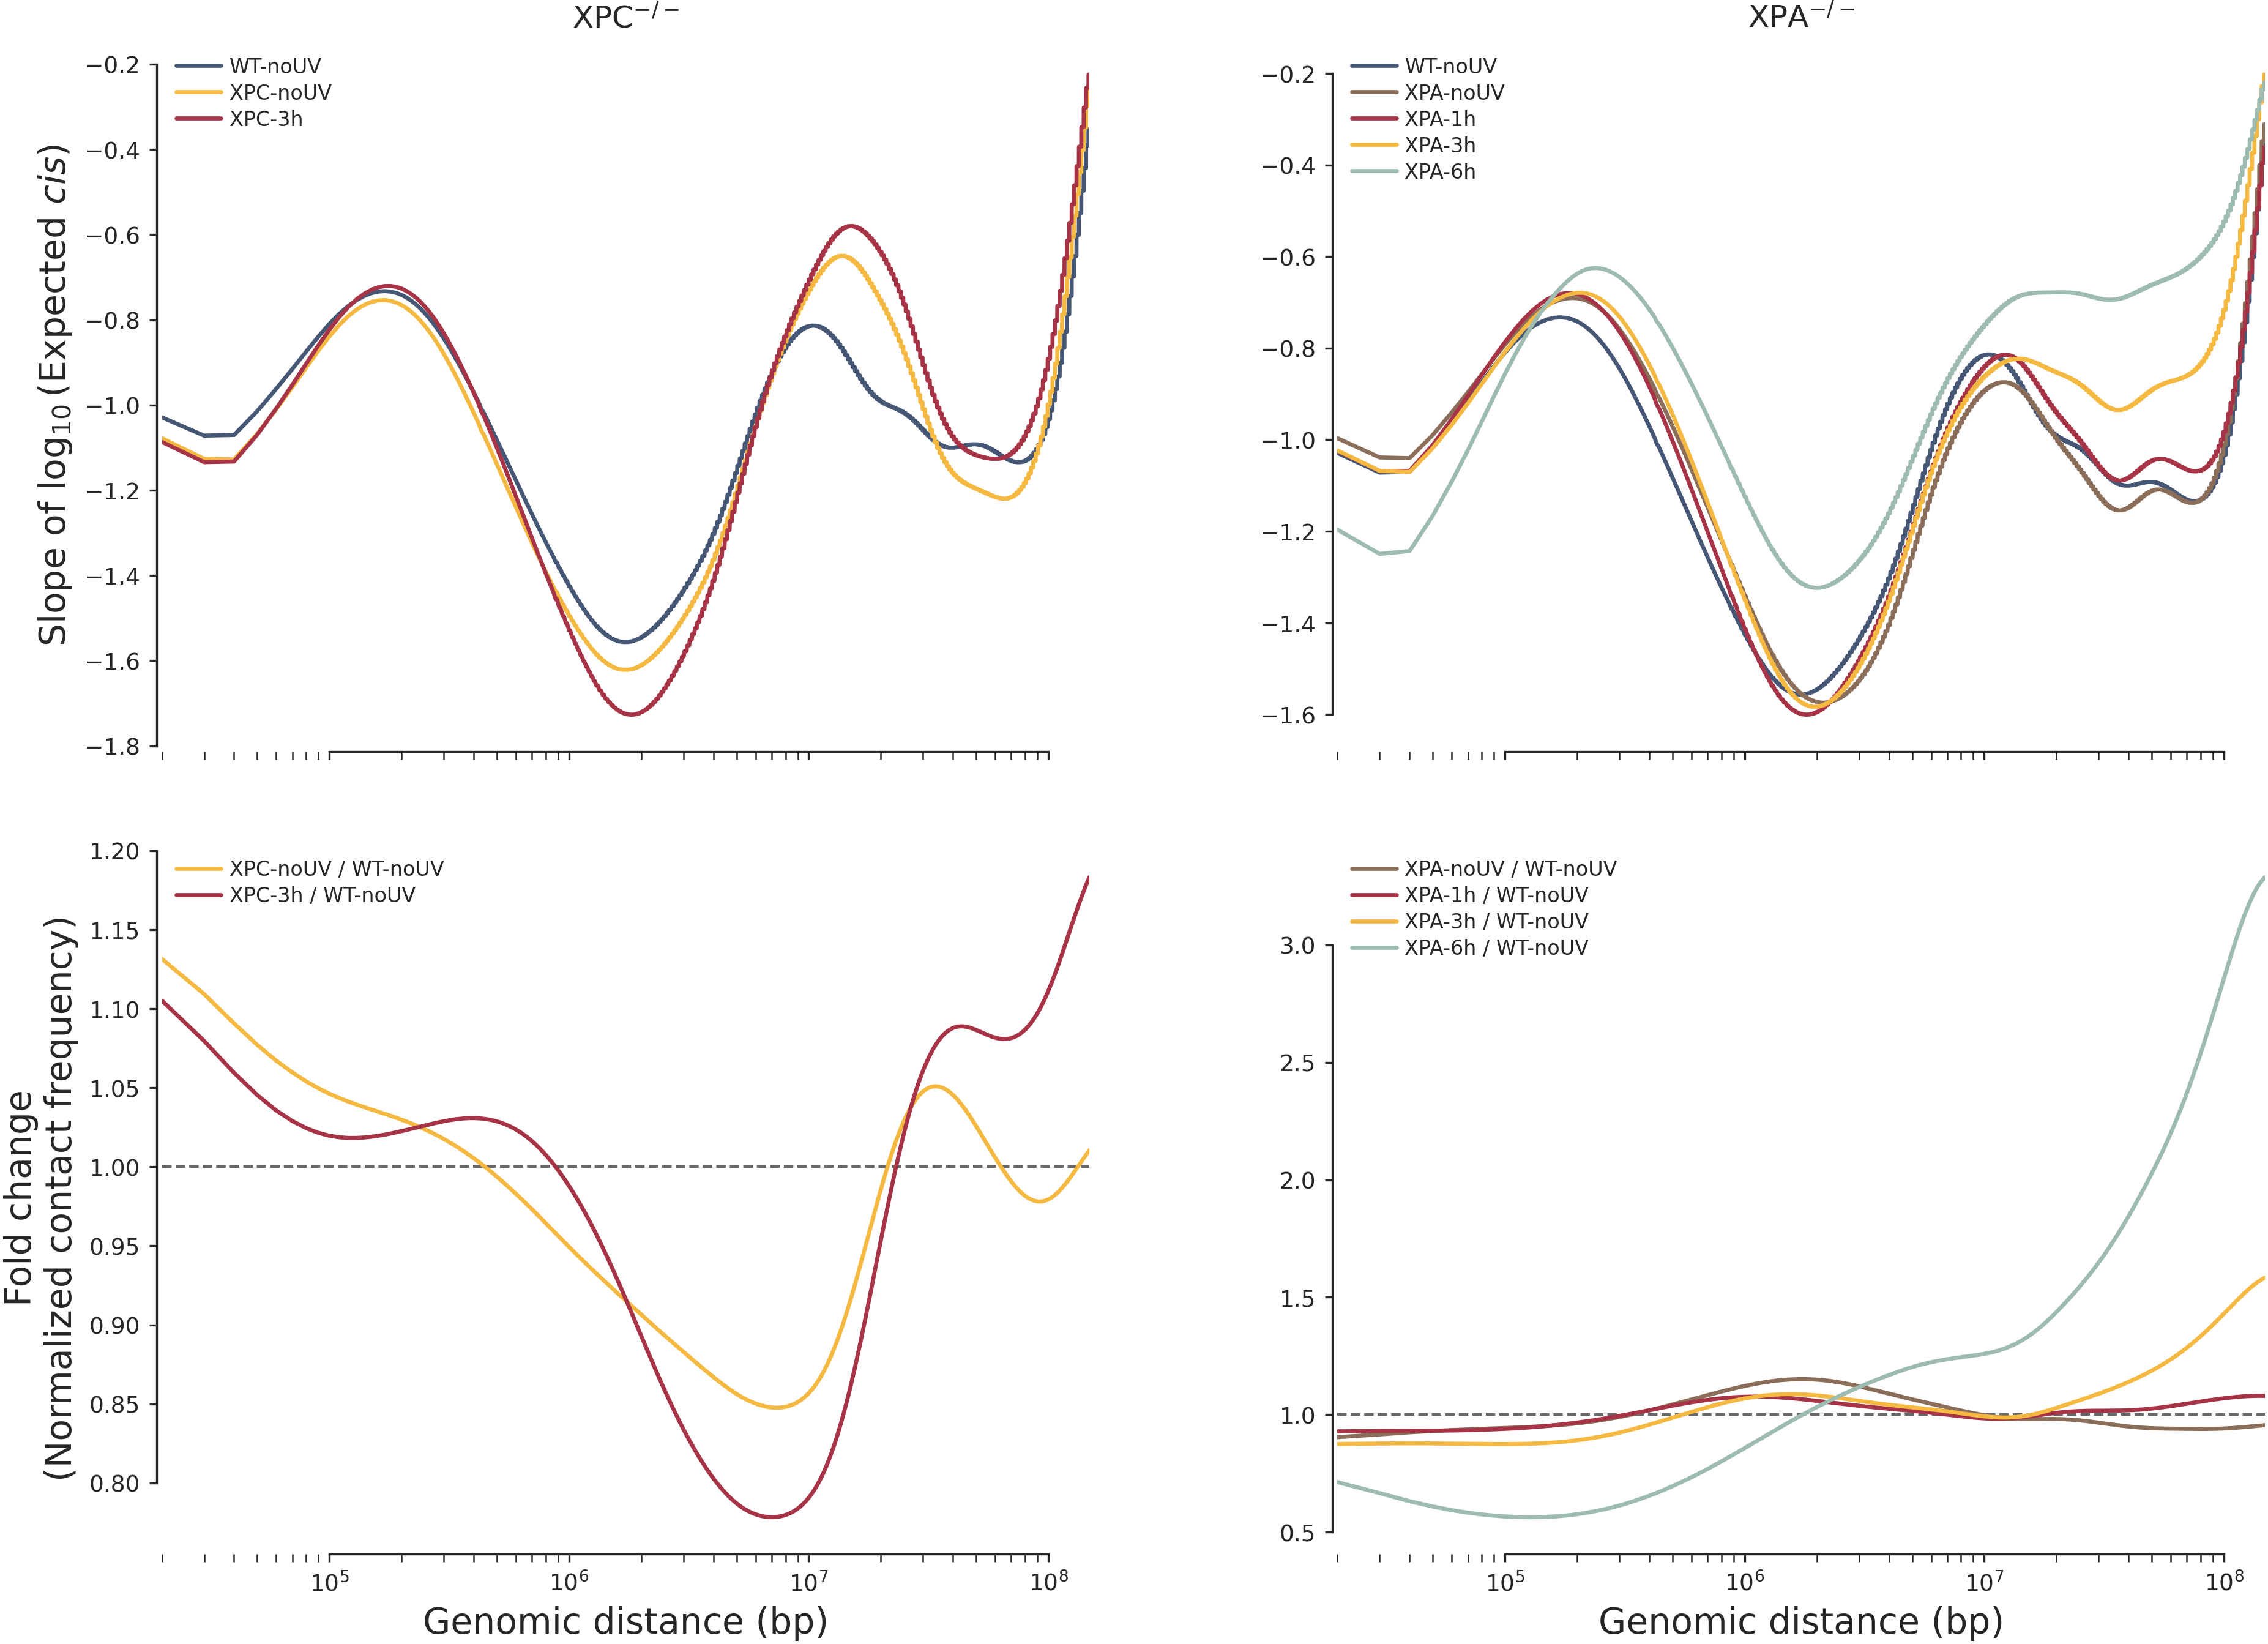

In [9]:

fig, axs = plot_ko_2x2(
    cis_decay_dict=cis_decay_dict,
    colors=colors,
    comp_base="WTnoUV",
    xpc_comps=("XPCnoUV", "XPC3h"),
    xpa_comps=("XPAnoUV", "XPA1h", "XPA3h", "XPA6h"),
)


fig.savefig("/home/carlos/Clone/ggner-3d/figs/decay/cis_derivative_and_foldchange_ko_2x2.svg")